# Day-ahead price vs. wind and solar generation
Germany, 21 September 2026. Data from the ingestion script (`data/processed/`).

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(
    "../data/processed/energy_2026-09-21.csv",
    parse_dates=["timestamp_utc"],
)
df["time_berlin"] = df["timestamp_utc"].dt.tz_convert("Europe/Berlin")
df.head()

,unix_seconds,wind_offshore_mw,wind_onshore_mw,solar_mw,price_eur_mwh,timestamp_utc,time_berlin
0,1789941600,1784.6,30015.1,0.0,50.68,2026-09-20 22:00:00+00:00,2026-09-21 00:00:00+02:00
1,1789942500,1831.9,30255.5,0.0,50.29,2026-09-20 22:15:00+00:00,2026-09-21 00:15:00+02:00
2,1789943400,1867.6,30464.9,0.0,45.28,2026-09-20 22:30:00+00:00,2026-09-21 00:30:00+02:00
3,1789944300,1869.1,30749.2,0.0,40.81,2026-09-20 22:45:00+00:00,2026-09-21 00:45:00+02:00
4,1789945200,2091.7,30669.7,0.0,45.61,2026-09-20 23:00:00+00:00,2026-09-21 01:00:00+02:00


Text(0.5, 1.0, 'Germany, 21 Sept 2026: the price drops to 0 €/MWh at the solar peak')

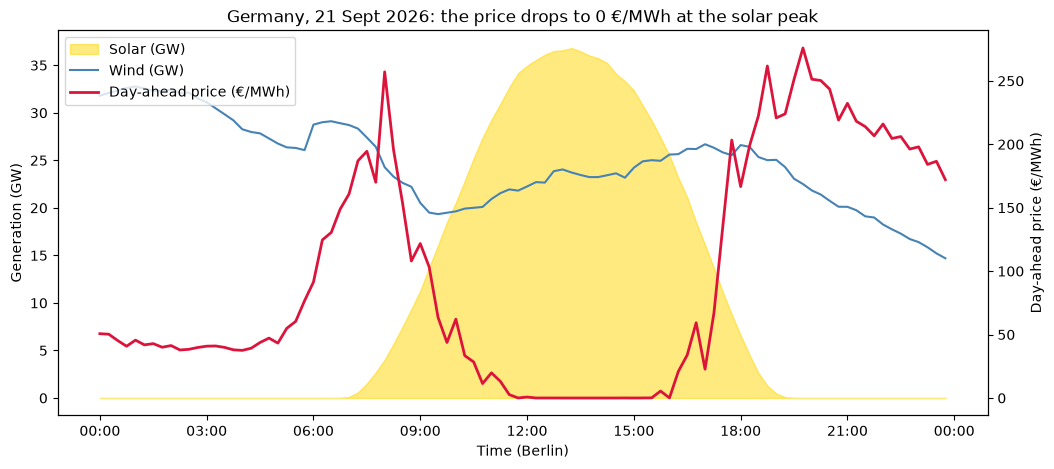

In [2]:
fig, ax_power = plt.subplots(figsize=(12, 5))

ax_power.fill_between(
    df["time_berlin"], df["solar_mw"] / 1000,
    color="gold", alpha=0.5, label="Solar (GW)",
)
ax_power.plot(
    df["time_berlin"], (df["wind_onshore_mw"] + df["wind_offshore_mw"]) / 1000,
    color="steelblue", label="Wind (GW)",
)
ax_power.set_xlabel("Time (Berlin)")
ax_power.set_ylabel("Generation (GW)")
ax_power.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="Europe/Berlin"))

ax_price = ax_power.twinx()
ax_price.plot(
    df["time_berlin"], df["price_eur_mwh"],
    color="crimson", linewidth=2, label="Day-ahead price (€/MWh)",
)
ax_price.set_ylabel("Day-ahead price (€/MWh)")

handles_power, labels_power = ax_power.get_legend_handles_labels()
handles_price, labels_price = ax_price.get_legend_handles_labels()
ax_power.legend(handles_power + handles_price, labels_power + labels_price, loc="upper left")

ax_power.set_title("Germany, 21 Sept 2026: the price drops to 0 €/MWh at the solar peak")

In [3]:
output_folder = Path("../docs/images")
output_folder.mkdir(parents=True, exist_ok=True)
fig.savefig(output_folder / "price_vs_solar_2026-09-21.png", dpi=150, bbox_inches="tight")
plt.show()